# Reaksjonskinetikk

## Reaksjonsrater

Vi har brukt lineær algebra til å balansere reaksjonsligninger, av type

$$\nu_1 X_1 + \ldots + \nu_d X_d = 0$$

For å forstår hvordan konsentrasjon av alle stoffene endrer seg ved tid trenger vi differensialligninger. Det sentrale begrepet reaksjonsraten $v$, definert som
$$
v(t) = \frac{1}{\nu_i} \frac{d[X_i]}{dt},
$$

som er uavhengig av $i$, men som regel avhengig av konsentrasjonene $[X_i]$. De vanligste lover har potenslover av formen
$$
v = k[X_1]^{n_1}\cdots[X_d]^{n_d}
$$

## En konsentrasjon

La oss ta først den enkleste mulig situasjon, $v=k[X_1]^{n_1}$

Vi får en differensialligning

$$
\frac{d[X_1]}{dt} = -\nu_1 k[X_1]^{n_1}
$$

## Eksempler

Det virker veldig abstrakt. Vi skal fokuserer på to eksempler:

1. $H_2 O_2 \rightarrow H_2 O + \frac{1}{2} O_2$
2. $N O_2 + CO \rightarrow NO + C O_2$

I første tilfelle er raten $v = k [H_2 O_2]$. Hvis vi lar $x=[H_2 O_2]$, får vi en ligning

$$
\frac{dx}{dt} = -kx
$$

I den andre er raten $v = k [N O_2]^2$. Hvis vi lar $x=[N O_2]$ får vi

$$
\frac{dx}{dt} = -kx^2
$$

## Temperatur

Konstanten er som regel ikke så konstant likevel. Den er blant annet avhengig av temperatur. Den klassiske ligningen er \textit{Arrhenius ligning}

$$
k = A \exp\left(\frac{-E}{RT}\right),
$$

hvor $A$ er en konstant, $E$ er aktiveringsenergi til reaksjonen, $R$ er gass-konstanten og $T$ er (absolutt, dvs i Kelvin) temperatur.

## Oppgave 1

1. Løs ligningen over for det spesielle tilfelle... ($n=1$)
2. Løs ligningen med $n=2$
3. Anta nå at reaksjonsraten er temperaturavhengig, slik at $k=k(T(t))$. Bruk koden under til å løse et av systemene over når temperaturen varierer seg. Sammenlign resultatene.

Du kan ta $A=2\cdot10^5$ s$^{-1}$ og $E=14.8$ kJ/mol for den første ligningen, og $A=4.5\cdot10^{10}$ s$^{-1}$ og $E=51.0$ kJ/mol for den andre.

En mulighet er å forandre temperaturen slik at $T=295 + 10 sin(t)$.

529.8725274183691


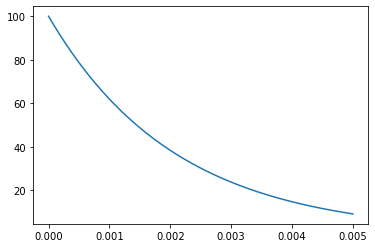

In [16]:
import numpy as np
from scipy.constants import R
import matplotlib.pyplot as plt

def euler(f,x0,a,b,N):
    t = np.linspace(a,b,N)
    x = np.zeros(N)
    x[0] = x0
    for i in np.arange(N-1):
        x[i+1] = x[i] + (t[i+1]-t[i])*(f(x[i],t[i]))
    return x,t

def temperatur(t):
    return 295 + 10*np.sin(t)

def arate(A,T,E):
    return A*np.exp(-E/(R*T))

def rate(x, t):
    A = 2e5
    E = 1.48e4
    return -arate(A, temperatur(t), E)*x

x, t = euler(rate, 100, 0, 0.005, 1000)

fig, ax = plt.subplots()

ax.plot(t,x)

print(arate(2e5,300,1.48e4))

## To veier

La oss anta at $\nu_1 X_1 = -\nu_2 X_2$, men at reaksjonen går begge veier.

Ligningene blir

$$
\begin{align}
\frac{d[X_1]}{dt} &= a[X_1] - b[X_2] \\
\frac{d[X_2]}{dt} &= -a[X_1] + b[X_2]
\end{align}
$$

Her er den forlengs reaksjonsrate $v_f = a[X_1]$, og den baklengs $v_b = b[X_2]$. Konstantene vil typisk følge en Arrenhius ligning, akkurat som før.

## Sykloheksan

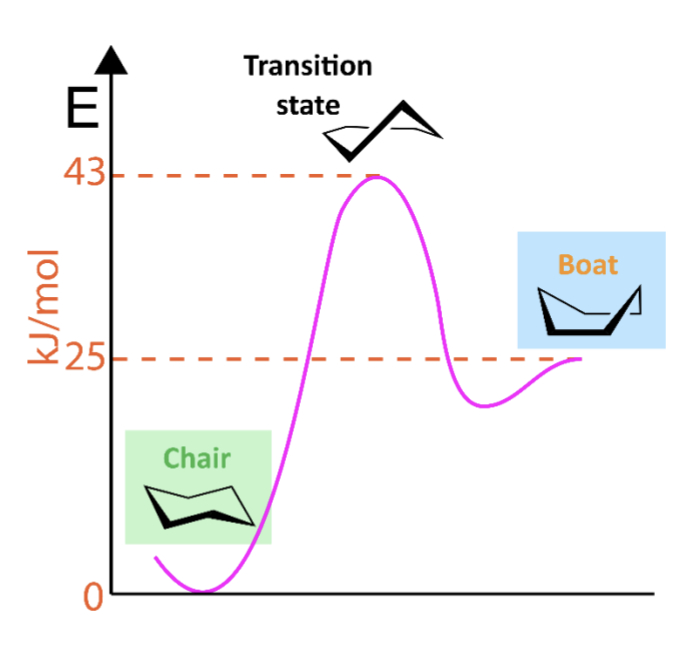

Den norske kjemiker Odd Hassel fikk nobeprisen for hans arbeid på det nydelige stoffet $\textit{sykloheksan}$. Den tar to former, båt og stol.

$$
\mathrm{Sykloheksan}_{\mathrm{båt}} \rightleftharpoons \mathrm{Sykloheksan}_{\mathrm{stol}}
$$

## Reaksjonsratene

Reaksjonen har to rater, en forlengs og en baklengs. Begge reaksjonsrater er førsteordens, slik at vi får ligningssystemet

$$
\begin{align}
\frac{d[X_1]}{dt} &= -a[X_1] + b[X_2] \\
\frac{d[X_2]}{dt} &= a[X_1] - b[X_2]
\end{align}
$$

hvor $[X_1]$ er konsentrasjon av båt og $[X_2]$ er konsentrasjon av stol. Vi har

$$
a = A \exp\left(\frac{-E_a}{RT}\right),
$$

hvor $A=6.15\cdot 10^{11}$ s$^{-1}$, og $E_a=18$ kJ/mol. På lignende måte er

$$
b = B \exp\left(\frac{-E_b}{RT}\right),
$$

hvor $B = 1.48\cdot 10^{12}$ s$^{-1}$, og $E_b=43$ kJ/mol.

## Oppgave 2

1. Skriv om systemet til en andre ordens ligning
2. Løs systemet
3. Hva tror du kommer til å skje når $t\rightarrow\infty$?

Hint: 1 er ikke så lett! Deriver først ligningen for $[X_1]$ på begge sider og sett inn ligningen for $\frac{d[X_2]}{dt}$. Sett da inn

$$
b[X_2] = \frac{d[X_1]}{dt} + a[X_1]
$$

For å få et fullstendig svar på 3 er det lettest å løse systemet numerisk og/eller bruke teorien som kommer senere i matte 1. Det går vi nærmere inn i i den 3. øvingen!